
# Lung Cancer Detection Notebook — Fixed and Ordered
This version is reorganized so the cells run in the correct order and uses **10-fold stratified cross-validation**.

### What was fixed
- Reordered cells so all variables and functions are defined before use
- Removed broken/empty duplicate cells
- Integrated **10-fold CV** into a clean training workflow
- Kept the improved preprocessing and EfficientNet-based classifier
- Added fold-by-fold and aggregated reporting


In [12]:

# If needed in Colab
# !pip -q install datasets scikit-learn

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset, ClassLabel, Features
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## Configuration

In [13]:

IMG_SIZE = 224
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
N_SPLITS = 10
WARMUP_EPOCHS = 8
FINETUNE_EPOCHS = 6

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of CV folds:", N_SPLITS)


Image size: 224
Batch size: 16
Number of CV folds: 10


## Load dataset

In [14]:

ds = load_dataset("irfansadiqrahat/lung-cancer")
print(ds)
print(ds["train"].features)


Resolving data files:   0%|          | 0/400 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/295 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 400
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 72
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 295
    })
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['adenocarcinoma', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'])}


## Optional label remapping

In [15]:

label_mapping_dict = {
    "adenocarcinoma": "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib": "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",

    "large.cell.carcinoma": "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa": "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",

    "normal": "normal",

    "squamous.cell.carcinoma": "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa": "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
}

original_class_label = ds["train"].features["label"]
new_label_names = sorted(list(set(label_mapping_dict.values())))

new_features = Features({
    "image": ds["train"].features["image"],
    "label": ClassLabel(names=new_label_names)
})

def remap_and_cast_labels(example):
    current_label_str = original_class_label.int2str(example["label"])
    mapped_label_str = label_mapping_dict[current_label_str]
    example["label"] = new_label_names.index(mapped_label_str)
    return example

ds = ds.map(remap_and_cast_labels, features=new_features)

train_dataset = ds["train"]
valid_dataset = ds["validation"]
test_dataset = ds["test"]

CLASS_NAMES = train_dataset.features["label"].names
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Train / Val / Test:", len(train_dataset), len(valid_dataset), len(test_dataset))


Classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Train / Val / Test: 400 72 295


## Inspect original image sizes

In [16]:

print("Train image size:", train_dataset[0]["image"].size)
print("Validation image size:", valid_dataset[0]["image"].size)
print("Test image size:", test_dataset[0]["image"].size)


Train image size: (397, 243)
Validation image size: (315, 245)
Test image size: (381, 282)


## Preprocess images

In [17]:
from datasets import Array3D, Features
from PIL import Image
import numpy as np

def pad_resize_grayscale_rgb(example):
    img = example["image"]
    # Keep unwrapping from lists until we get a non-list object
    while isinstance(img, list) and len(img) > 0:
        img = img[0]

    # Handle cases where `img` might already be a numpy array
    if isinstance(img, np.ndarray):
        # Assuming grayscale or RGB. If RGB, convert to PIL RGB; if grayscale, convert to PIL L
        if img.ndim == 3 and img.shape[-1] == 3: # RGB numpy array
            img = Image.fromarray(img.astype(np.uint8), 'RGB')
        elif img.ndim == 3 and img.shape[-1] == 1: # Grayscale numpy array (H, W, 1)
            img = Image.fromarray(img.squeeze().astype(np.uint8), 'L')
        elif img.ndim == 2: # Grayscale numpy array (H, W)
            img = Image.fromarray(img.astype(np.uint8), 'L')
        else:
            print(f"Warning: numpy array of unexpected shape {img.shape}. Returning a blank PIL image.")
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color = 'black')
    elif not isinstance(img, Image.Image):
        # This case should ideally not be reached if the above numpy check works
        print(f"Warning: example['image'] is not a PIL Image object (type: {type(img)}). Returning a blank PIL image.")
        img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color = 'black')

    # Now `img` should be a PIL Image object, proceed as before
    img = img.convert("L")
    img = tf.keras.preprocessing.image.img_to_array(img)   # (H, W, 1)
    img = tf.convert_to_tensor(img, dtype=tf.float32)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), preserve_aspect_ratio=True)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)

    # Add contrast adjustment to make dark images more visible
    # Assuming pixel values are in [0, 255] float32. Contrast factor > 1 increases contrast.
    img = tf.image.adjust_contrast(img, contrast_factor=2.0)
    # Clip values to ensure they stay within expected range after contrast adjustment
    img = tf.clip_by_value(img, 0.0, 255.0)

    # Repeat grayscale channel to 3 channels for EfficientNet
    img = tf.repeat(img, repeats=3, axis=-1)
    img = tf.cast(tf.round(img), tf.uint8).numpy()
    example["image"] = img
    return example

# Define new features to explicitly store the image as a 3D array
# We need to get the current label features from one of the datasets after remapping
current_label_features = train_dataset.features["label"]

processed_dataset_features = Features({
    "image": Array3D(shape=(IMG_SIZE, IMG_SIZE, 3), dtype="uint8"),
    "label": current_label_features
})

train_dataset = train_dataset.map(pad_resize_grayscale_rgb, features=processed_dataset_features)
valid_dataset = valid_dataset.map(pad_resize_grayscale_rgb, features=processed_dataset_features)
test_dataset  = test_dataset.map(pad_resize_grayscale_rgb, features=processed_dataset_features)

# Explicitly set the format to 'numpy' to ensure direct access returns numpy arrays
train_dataset.set_format(type="numpy", columns=["image", "label"])
valid_dataset.set_format(type="numpy", columns=["image", "label"])
test_dataset.set_format(type="numpy", columns=["image", "label"])

print("Processed train image shape:", train_dataset[0]["image"].shape)


Processed train image shape: (224, 224, 3)


## Examples of all classes across datasets


--- Displaying one example per class for Train dataset ---


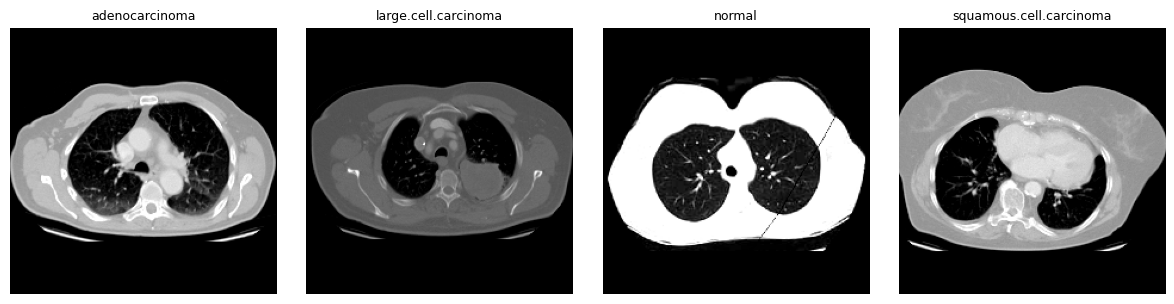


--- Displaying one example per class for Validation dataset ---


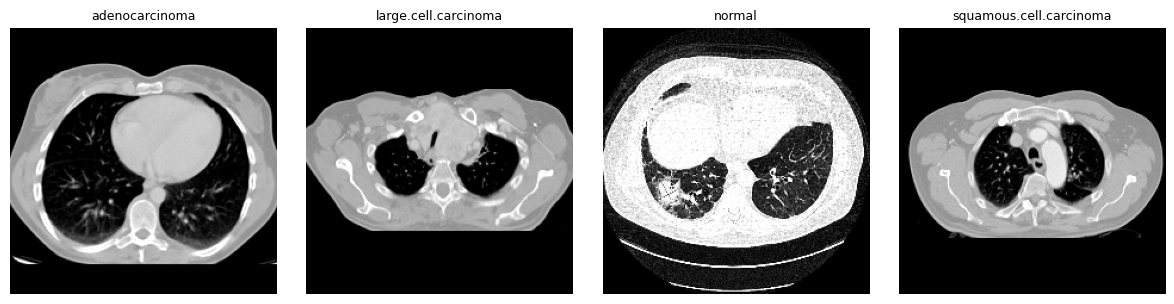


--- Displaying one example per class for Test dataset ---


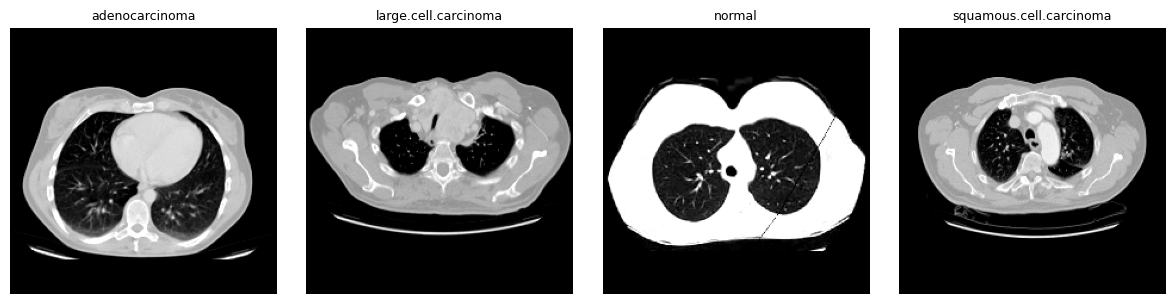

In [18]:
def display_class_examples(dataset, dataset_name, class_names):
    print(f"\n--- Displaying one example per class for {dataset_name} dataset ---")
    displayed_classes = set()
    fig, axes = plt.subplots(1, len(class_names), figsize=(3 * len(class_names), 3))
    if len(class_names) == 1: # Handle case with only one class
        axes = [axes]
    axes = axes.ravel()

    found_count = 0
    for i in range(len(dataset)):
        sample = dataset[i]
        label_idx = sample["label"]
        class_name = class_names[label_idx]

        if class_name not in displayed_classes:
            axes[found_count].imshow(sample["image"])
            axes[found_count].set_title(class_name.split("_")[0], fontsize=9)
            axes[found_count].axis("off")
            displayed_classes.add(class_name)
            found_count += 1

        if found_count == len(class_names):
            break

    # Hide any unused subplots if fewer examples were found than expected
    for j in range(found_count, len(class_names)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Display examples for each dataset
display_class_examples(train_dataset, "Train", CLASS_NAMES)
display_class_examples(valid_dataset, "Validation", CLASS_NAMES)
display_class_examples(test_dataset, "Test", CLASS_NAMES)


## Convert to NumPy

In [19]:

def dataset_to_numpy(hf_dataset):
    images = np.stack(hf_dataset["image"]).astype("float32")
    labels = np.array(hf_dataset["label"]).astype("int32")
    return images, labels

X_train, y_train = dataset_to_numpy(train_dataset)
X_val, y_val = dataset_to_numpy(valid_dataset)
X_test, y_test = dataset_to_numpy(test_dataset)

# Use train + validation together for 10-fold cross-validation
X_cv = np.concatenate([X_train, X_val], axis=0)
y_cv = np.concatenate([y_train, y_val], axis=0)

print("X_cv:", X_cv.shape, "y_cv:", y_cv.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


X_cv: (472, 224, 224, 3) y_cv: (472,)
X_test: (295, 224, 224, 3) y_test: (295,)


### Class Distribution in Each Dataset

In [20]:
print('--- Training Dataset Class Counts ---')
for i, count in enumerate(np.bincount(y_train)):
    print(f'Class {CLASS_NAMES[i]}: {count} samples')

print('\n--- Validation Dataset Class Counts ---')
for i, count in enumerate(np.bincount(y_val)):
    print(f'Class {CLASS_NAMES[i]}: {count} samples')

print('\n--- Test Dataset Class Counts ---')
for i, count in enumerate(np.bincount(y_test)):
    print(f'Class {CLASS_NAMES[i]}: {count} samples')

--- Training Dataset Class Counts ---
Class adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 100 samples
Class large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 100 samples
Class normal: 100 samples
Class squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 100 samples

--- Validation Dataset Class Counts ---
Class adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 23 samples
Class large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 21 samples
Class normal: 13 samples
Class squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 15 samples

--- Test Dataset Class Counts ---
Class adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 100 samples
Class large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 51 samples
Class normal: 54 samples
Class squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 90 samples


## Data augmentation

In [21]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")


## Build model

In [22]:
def build_model(img_size=224, num_classes=4, base_trainable=False, lr=1e-3):
    inputs = tf.keras.Input(shape=(img_size, img_size, 3))

    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )
    base_model.trainable = base_trainable

    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.40)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.30)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_preview = build_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES, base_trainable=False, lr=1e-3)
model_preview.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,416,039 (16.85 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Cross-validation helper

In [23]:

def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def compute_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, weights)}

def compute_specificity(cm):
    values = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        values.append(spec)
    return values


## Run 10-fold stratified cross-validation

In [24]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_results = []
best_fold_model = None
best_fold_score = -1
best_fold_number = None

print(f"Starting {N_SPLITS}-Fold Stratified Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    X_train_fold, X_val_fold = X_cv[train_idx], X_cv[val_idx]
    y_train_fold, y_val_fold = y_cv[train_idx], y_cv[val_idx]

    train_ds_fold = make_ds(X_train_fold, y_train_fold, training=True)
    val_ds_fold = make_ds(X_val_fold, y_val_fold, training=False)

    class_weights = compute_class_weights(y_train_fold)
    print("Class weights:", class_weights)

    model_fold = build_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES, base_trainable=False, lr=1e-3)

    callbacks_stage1 = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ]

    print("Stage 1: warm-up")
    model_fold.fit(
        train_ds_fold,
        validation_data=val_ds_fold,
        epochs=WARMUP_EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks_stage1,
        verbose=1
    )

    base_model_fold = None
    for layer in model_fold.layers:
        if isinstance(layer, tf.keras.Model) and "efficientnetb0" in layer.name.lower():
            base_model_fold = layer
            break

    if base_model_fold is not None:
        base_model_fold.trainable = True
        for layer in base_model_fold.layers[:-40]:
            layer.trainable = False

    model_fold.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy"
        ]
    )

    callbacks_stage2 = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1),
    ]

    print("Stage 2: fine-tuning")
    model_fold.fit(
        train_ds_fold,
        validation_data=val_ds_fold,
        epochs=FINETUNE_EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks_stage2,
        verbose=1
    )

    y_val_proba = model_fold.predict(val_ds_fold, verbose=0)
    y_val_pred = np.argmax(y_val_proba, axis=1)

    fold_accuracy = accuracy_score(y_val_fold, y_val_pred)
    fold_precision = precision_score(y_val_fold, y_val_pred, average="weighted", zero_division=0)
    fold_recall = recall_score(y_val_fold, y_val_pred, average="weighted", zero_division=0)
    fold_f1 = f1_score(y_val_fold, y_val_pred, average="weighted", zero_division=0)

    try:
        fold_auc = roc_auc_score(y_val_fold, y_val_proba, multi_class="ovr", average="weighted")
    except Exception:
        fold_auc = np.nan

    cm = confusion_matrix(y_val_fold, y_val_pred)
    specificity_macro = float(np.mean(compute_specificity(cm)))

    fold_results.append({
        "fold": fold,
        "accuracy": fold_accuracy,
        "precision_weighted": fold_precision,
        "recall_weighted": fold_recall,
        "f1_weighted": fold_f1,
        "auc_weighted_ovr": fold_auc,
        "specificity_macro": specificity_macro
    })

    print(f"Fold {fold} Accuracy: {fold_accuracy:.4f}")
    print(f"Fold {fold} Weighted F1: {fold_f1:.4f}")
    print(f"Fold {fold} Macro Specificity: {specificity_macro:.4f}")

    if fold_f1 > best_fold_score:
        best_fold_score = fold_f1
        best_fold_model = model_fold
        best_fold_number = fold

    tf.keras.backend.clear_session()

print("\nCross-validation finished.")
print("Best fold:", best_fold_number, "| Best weighted F1:", round(best_fold_score, 4))

Starting 10-Fold Stratified Cross-Validation...

===== Fold 1/10 =====
Class weights: {0: 0.9636363636363636, 1: 0.9724770642201835, 2: 1.0392156862745099, 3: 1.029126213592233}
Stage 1: warm-up
Epoch 1/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - accuracy: 0.5259 - loss: 1.2539 - val_accuracy: 0.5417 - val_loss: 0.9791 - learning_rate: 0.0010
Epoch 2/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6604 - loss: 0.8825 - val_accuracy: 0.5417 - val_loss: 0.9791 - learning_rate: 0.0010
Epoch 3/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7335 - loss: 0.7064 - val_accuracy: 0.5833 - val_loss: 0.8877 - learning_rate: 0.0010
Epoch 4/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7972 - loss: 0.5422 - val_accuracy: 0.5833 - val_loss: 0.9351 - learning_rate: 0.0010
Epoch 5/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8208 - loss: 0.4594 - val_accuracy: 0.6250 - val_loss: 0.8341 - learning_rate: 0.0010
Epoch 6/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - a

Fold 4 Accuracy: 0.6809
Fold 4 Weighted F1: 0.6359
Fold 4 Macro Specificity: 0.8948

===== Fold 5/10 =====
Class weights: {0: 0.9572072072072072, 1: 0.9747706422018348, 2: 1.051980198019802, 3: 1.0216346153846154}
Stage 1: warm-up
Epoch 1/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.5059 - loss: 1.4143 - val_accuracy: 0.6383 - val_loss: 0.9483 - learning_rate: 0.0010
Epoch 2/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6212 - loss: 0.9948 - val_accuracy: 0.5319 - val_loss: 0.8932 - learning_rate: 0.0010
Epoch 3/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7412 - loss: 0.6567 - val_accuracy: 0.6809 - val_loss: 0.7424 - learning_rate: 0.0010
Epoch 4/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7247 - loss: 0.6770 - val_accuracy: 0.7447 - val_loss: 0.6401 - learning_rate: 0.0010
Epoch 5/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7859 - loss: 0.5071 - val_accuracy: 0.8085 - val_loss: 0.5807 - learning_rate: 0.0010
Epoch 6/8
27/27 ━

## Aggregate CV results

In [25]:

results_df = pd.DataFrame(fold_results)
results_df


,fold,accuracy,precision_weighted,recall_weighted,f1_weighted,auc_weighted_ovr,specificity_macro
0,1,0.687500,0.769097,0.687500,0.668009,0.909904,0.895635
1,2,0.791667,0.810069,0.791667,0.771843,0.974603,0.930357
2,3,0.744681,0.768685,0.744681,0.744008,0.922933,0.915651
3,4,0.680851,0.712119,0.680851,0.635943,0.926784,0.894818
4,5,0.765957,0.761375,0.765957,0.761625,0.952904,0.922024
5,6,0.744681,0.773538,0.744681,0.730383,0.942080,0.915675
6,7,0.744681,0.786559,0.744681,0.735722,0.959507,0.915873
7,8,0.829787,0.882724,0.829787,0.823938,0.962310,0.942857
8,9,0.723404,0.781464,0.723404,0.702966,0.941050,0.907341
9,10,0.829787,0.863382,0.829787,0.817771,0.977508,0.942857


In [26]:

summary = results_df.agg(["mean", "std"]).round(4)
summary


,fold,accuracy,precision_weighted,recall_weighted,f1_weighted,auc_weighted_ovr,specificity_macro
mean,5.5000,0.7543,0.7909,0.7543,0.7392,0.9470,0.9183
std,3.0277,0.0517,0.0500,0.0517,0.0597,0.0225,0.0169


## Evaluate best fold model on the holdout test set

In [27]:
test_ds = make_ds(X_test, y_test, training=False)

# Rebuild and retrain on the best fold split if best_fold_model was cleared from session
# Safer approach: directly use the stored best-fold number to recreate and retrain that fold once.
best_train_idx, best_val_idx = list(skf.split(X_cv, y_cv))[best_fold_number - 1]

X_train_best, X_val_best = X_cv[best_train_idx], X_cv[best_val_idx]
y_train_best, y_val_best = y_cv[best_train_idx], y_cv[best_val_idx]

train_ds_best = make_ds(X_train_best, y_train_best, training=True)
val_ds_best = make_ds(X_val_best, y_val_best, training=False)

class_weights_best = compute_class_weights(y_train_best)

final_model = build_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES, base_trainable=False, lr=1e-3)

callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]
final_model.fit(
    train_ds_best,
    validation_data=val_ds_best,
    epochs=WARMUP_EPOCHS,
    class_weight=class_weights_best,
    callbacks=callbacks_stage1,
    verbose=1
)

base_model_final = None
for layer in final_model.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnetb0" in layer.name.lower():
        base_model_final = layer
        break

if base_model_final is not None:
    base_model_final.trainable = True
    for layer in base_model_final.layers[:-40]:
        layer.trainable = False

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1),
]
final_model.fit(
    train_ds_best,
    validation_data=val_ds_best,
    epochs=FINETUNE_EPOCHS,
    class_weight=class_weights_best,
    callbacks=callbacks_stage2,
    verbose=1
)

y_proba = final_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)

accuracy = accuracy_score(y_test, y_pred)
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
weighted_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
auc_ovr = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")

cm = confusion_matrix(y_test, y_pred)
specificities = compute_specificity(cm)

print("Accuracy:", round(accuracy, 4))
print("Weighted Precision:", round(weighted_precision, 4))
print("Weighted Recall / Sensitivity:", round(weighted_recall, 4))
print("Weighted F1:", round(weighted_f1, 4))
print("Weighted One-vs-Rest AUC:", round(auc_ovr, 4))
print("\nPer-class specificity:")
for cls, spec in zip(CLASS_NAMES, specificities):
    print(f"{cls}: {spec:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))


Epoch 1/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 180ms/step - accuracy: 0.4824 - loss: 1.4320 - val_accuracy: 0.5319 - val_loss: 1.0002 - learning_rate: 0.0010
Epoch 2/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.6824 - loss: 0.8432 - val_accuracy: 0.6596 - val_loss: 0.9177 - learning_rate: 0.0010
Epoch 3/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7129 - loss: 0.6829 - val_accuracy: 0.5319 - val_loss: 0.8714 - learning_rate: 0.0010
Epoch 4/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7788 - loss: 0.5803 - val_accuracy: 0.7234 - val_loss: 0.7101 - learning_rate: 0.0010
Epoch 5/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8188 - loss: 0.5096 - val_accuracy: 0.7021 - val_loss: 0.6583 - learning_rate: 0.0010
Epoch 6/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8094 - loss: 0.4840 - val_accuracy: 0.7447 - val_loss: 0.6120 - learning_rate: 0.0010
Epoch 7/8
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8212 - loss: 0.5510 - val_accuracy

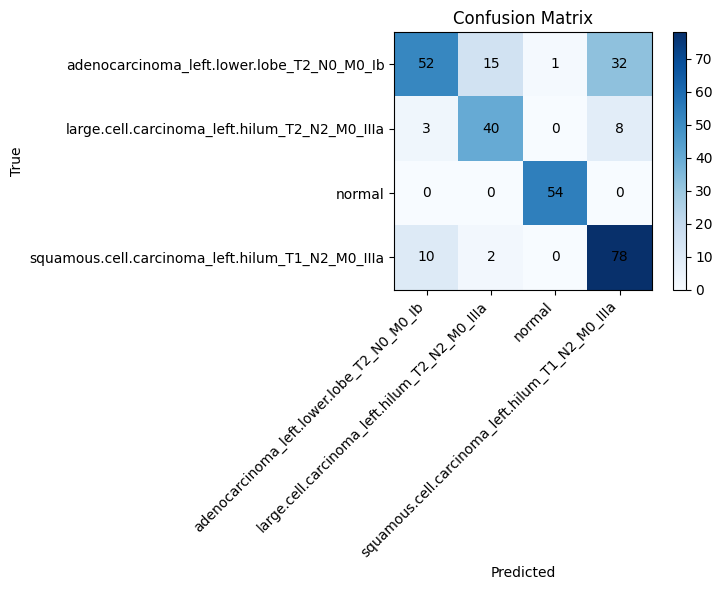

In [28]:

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


## Save final model

In [29]:

final_model.save("lung_cancer_detection_fixed_10fold.keras")
print("Saved model: lung_cancer_detection_fixed_10fold.keras")


Saved model: lung_cancer_detection_fixed_10fold.keras



## Notes
- This notebook now uses **10-fold stratified cross-validation** in the correct execution order.
- If Colab RAM or GPU memory becomes tight, lower `BATCH_SIZE` from **16** to **8**.
- The holdout test set remains separate from CV and is evaluated only after model selection.
